# Lab 1: Hands-on Time-series Anomaly Detection (TAD) for smart manufactoring


Goal: build a full sklearn pipeline sequentially and observe the impact of each addition:

    

1. Baseline model (no preprocessing)
2. Add scaling (StandardScaler) via Pipeline
3. Add dimensionality reduction (PCA)
4. Add hyperparameter tuning (RandomizedSearchCV) on the full pipeline
5. Build a similar pipeline, based on Random Forest


**After each step you have to fill in a short Markdown reflection**


## Import

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import os
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn import preprocessing
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import RandomizedSearchCV
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

## Utils
Function to plot a confusion matrix using seaborn

In [2]:
def seaborn_cm(cm, ax, tick_labels, fontsize=14, title=None, sum_actual="over_columns",
               xrotation=0, yrotation=0):
    """
    Function to plot a confusion matrix
    """
    from matplotlib import cm as plt_cmap
    group_counts = ["{:0.0f}".format(value) for value in cm.flatten()]
    if sum_actual == "over_columns":
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    elif sum_actual == "over_rows":
        cm = cm.astype('float') / cm.sum(axis=0)[:, np.newaxis]
    else:
        print("sum_actual must be over_columns or over_rows")
        exit()
    cm = np.nan_to_num(cm)
    mean_acc = np.mean(np.diag(cm)[cm.sum(axis=1) != 0])
    std_acc = np.std(np.diag(cm))
    group_percentages = ["{:0.0f}".format(value*100) for value in cm.flatten()]
    cm_labels = [f"{c}\n{p}%" for c, p in zip(group_counts, group_percentages)]
    cm_labels = np.asarray(cm_labels).reshape(len(tick_labels), len(tick_labels))
    sns.heatmap(cm,
                ax=ax,
                annot=cm_labels,
                fmt='',
                cbar=False,
                cmap=plt_cmap.Greys,
                linewidths=1, linecolor='black',
                annot_kws={"fontsize": fontsize},
                xticklabels=tick_labels,
                yticklabels=tick_labels)
    ax.set_yticklabels(ax.get_yticklabels(), size=fontsize, rotation=yrotation)
    ax.set_xticklabels(ax.get_xticklabels(), size=fontsize, rotation=xrotation)
    if title:
        title = f"{title}\nMean accuracy {mean_acc * 100:.1f} +- {std_acc * 100:.1f}"
    else:
        title = f"Mean accuracy {mean_acc * 100:.1f} +- {std_acc * 100:.1f}"
    ax.set_title(title)
    if sum_actual == "over_columns":
        ax.set_ylabel("Actual")
        ax.set_xlabel("Predicted")
    else:
        ax.set_ylabel("Predicted")
        ax.set_xlabel("Actual")
    ax.axis("off")  # Comment to see ticks

## Dataset loading

Note that the manual uploading of the dataset *df_features.csv* on this colab session is required.

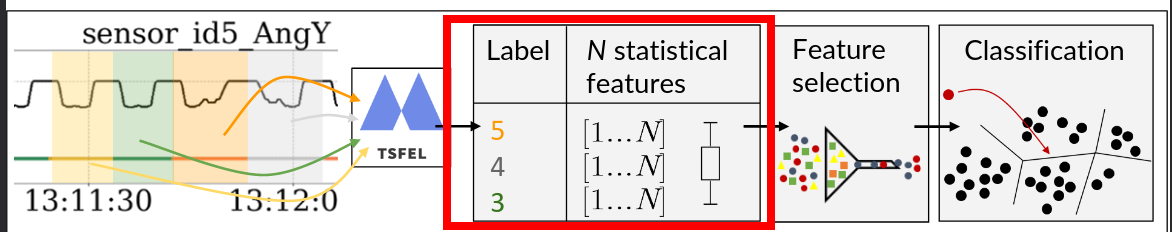

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# In Colab, if you upload the file manually, it will usually be available as "df_features.csv" in /content.
filepath = "/content/drive/MyDrive/lab/data/df_features.csv"
try:
    df_features = pd.read_csv(filepath)
except FileNotFoundError:
    print(f"{filepath} not found!\nHave you uploaded {filepath} in this session?!")

In [7]:
df_features.head(5)

,machine_nameKuka Robot_apparent_power-_Absolute energy,machine_nameKuka Robot_apparent_power-_Average power,machine_nameKuka Robot_apparent_power-_ECDF Percentile Count_0,machine_nameKuka Robot_apparent_power-_ECDF Percentile Count_1,machine_nameKuka Robot_apparent_power-_ECDF Percentile_0,machine_nameKuka Robot_apparent_power-_ECDF Percentile_1,machine_nameKuka Robot_apparent_power-_ECDF_0,machine_nameKuka Robot_apparent_power-_ECDF_1,machine_nameKuka Robot_apparent_power-_ECDF_2,machine_nameKuka Robot_apparent_power-_ECDF_3,...,sensor_id5_GyroZ-_Median,sensor_id5_GyroZ-_Median absolute deviation,sensor_id5_GyroZ-_Min,sensor_id5_GyroZ-_Peak to peak distance,sensor_id5_GyroZ-_Root mean square,sensor_id5_GyroZ-_Standard deviation,sensor_id5_GyroZ-_Variance,start,end,label
0,2.753289e+06,278110.023728,20.0,80.0,165.678116,166.391693,0.01,0.02,0.03,0.04,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2022-08-11 13:08:45.619,2022-08-11 13:08:55.619,0
1,2.755394e+06,278322.648720,20.0,80.0,165.733948,166.309937,0.01,0.02,0.03,0.04,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2022-08-11 13:08:55.619,2022-08-11 13:09:05.619,0
2,2.748381e+06,277614.192787,20.0,80.0,165.572784,165.925323,0.01,0.02,0.03,0.04,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2022-08-11 13:09:05.619,2022-08-11 13:09:15.619,0
3,2.749058e+06,277682.602178,20.0,80.0,165.572784,166.084869,0.01,0.02,0.03,0.04,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2022-08-11 13:09:15.619,2022-08-11 13:09:25.619,0
4,2.740634e+06,276831.705636,20.0,80.0,165.209900,165.876617,0.01,0.02,0.03,0.04,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2022-08-11 13:09:25.619,2022-08-11 13:09:35.619,0


## Check the dataset stats
You should have 973 samples (rows), each one showing 1638 features (columns).
The number of labels is 31 labels $\in$ [0, 30]

In [8]:
print("Dataset shape: ")
df_features.shape

Dataset shape: 


(973, 1638)

In [9]:
np.unique(df_features.label)
print(f"Found {len(np.unique(df_features.label))} labels")

Found 31 labels


## Labels distribution

This cell plots the distribution of the labels among classes.

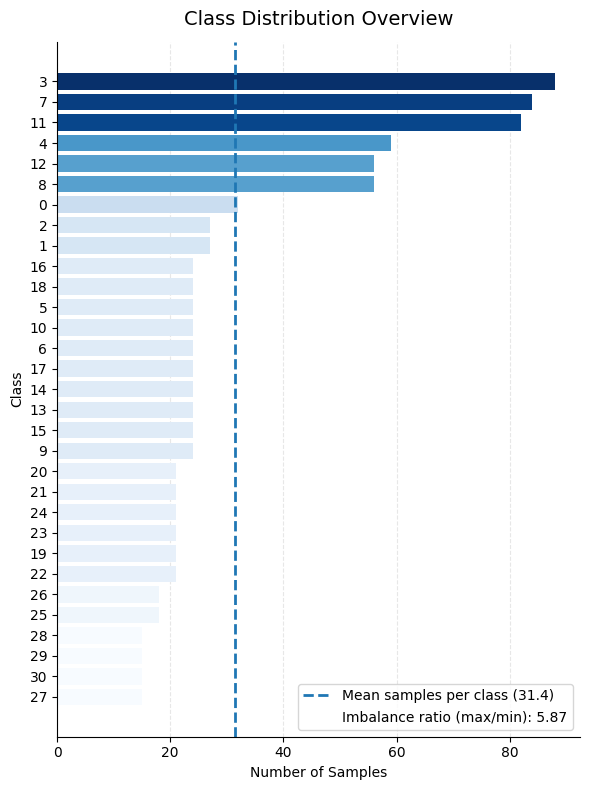

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

counts = df_features["label"].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(6, 8))

# Bars with gradient
norm = plt.Normalize(counts.min(), counts.max())
colors = plt.cm.Blues(norm(counts.values))
ax.barh(counts.index.astype(str), counts.values, color=colors)

# Mean reference line
mean_val = counts.mean()
mean_line = ax.axvline(
    mean_val,
    linestyle="--",
    linewidth=2
)

# Imbalance ratio
imbalance_ratio = counts.max() / counts.min()

# Create handles for legend text
ratio_handle = Line2D([], [], linestyle="none")

# Clean style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.xaxis.grid(True, linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

ax.set_title("Class Distribution Overview", fontsize=14, pad=12)
ax.set_xlabel("Number of Samples")
ax.set_ylabel("Class")

# Legend
ax.legend(
    handles=[mean_line, ratio_handle],
    labels=[
        f"Mean samples per class ({mean_val:.1f})",
        f"Imbalance ratio (max/min): {imbalance_ratio:.2f}"
    ],
    loc="lower right",
    frameon=True,
)

plt.tight_layout()
plt.show()

## Check if NaN exist

NaN should not be present.

In [11]:
df_features.isnull().values.any()

np.False_

## Assignment #1: Prepare data for train and test

[`Split arrays or matrices into random train and test subsets`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)

Note that the last three columns are the start, the end and the label corresponding to the action the robot is performing. Label is our gound truth, start and end can be dropped.

Use a reproducible and stratified split (important with many classes).



In [13]:
SEED = 42
np.random.seed(SEED)

df_train, df_test = train_test_split(df_features, test_size=0.2, stratify=df_features["label"], random_state=SEED)


In [14]:
# Separate features/target
drop_cols = ["label", "start", "end"]
X_train = df_train.drop(drop_cols, axis=1)
y_train = df_train["label"]

X_test = df_test.drop(drop_cols, axis=1)
y_test = df_test["label"]

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("Train labels:", y_train.nunique(), "| Test labels:", y_test.nunique())

Train shape: (778, 1635) | Test shape: (195, 1635)
Train labels: 31 | Test labels: 31


## Build a full sklearn Pipeline step-by-step

We build the modeling workflow **sequentially**.
After each step we measure performance and then write a short **consideration** based on the observed results.


The function below **returns a complete performance report**, used to assess the incremental improvement achieved at each step of the pipeline.

In [15]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

def evaluate_step(model, X_test, y_test, step_name):
    """
    Evaluate a fitted model on the test set.

    Parameters
    ----------
    model : fitted estimator or fitted sklearn Pipeline or fitted search object
        The fitted object can be:
        - a plain classifier (e.g. SVC)
        - a Pipeline (e.g. scaling + PCA + classifier)
        - a hyperparameter search object (e.g. RandomizedSearchCV)

    X_test : array-like
        Test features.

    y_test : array-like
        Test labels.

    step_name : str
        Name of the experiment/configuration, used for printing and tracking results.

    Returns
    -------
    r : dict
        Dictionary containing:
        - step: experiment name
        - acc: accuracy on the test set
        - bal_acc: balanced accuracy on the test set
        - f1_macro: macro-averaged F1 score on the test set
        - pred_s: prediction time in seconds
        - model: fitted model object
    """
    t0 = time.time()
    pred = model.predict(X_test)
    pred_s = time.time() - t0

    r = {
        "step": step_name,
        "acc": accuracy_score(y_test, pred),
        "bal_acc": balanced_accuracy_score(y_test, pred),
        "f1_macro": f1_score(y_test, pred, average="macro"),
        "pred_s": pred_s,
        "model": model
    }

    print("="*50)
    print(f"STEP: {step_name}")
    print(f"Accuracy:           {r['acc']:.3f}")
    print(f"Balanced Accuracy:  {r['bal_acc']:.3f}")
    print(f"Macro F1-score:     {r['f1_macro']:.3f}")
    print(f"Predict time (s):   {r['pred_s']:.2f}")
    print("="*50)

    return r

## Assignment #2.1 — Baseline model (no Pipeline)
We start with a plain [`SVC`](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC) to set a baseline with the following parameters:


*   C=1.0
*   kernel="rbf"
*   gamma="scale"
*   random_state=SEED




In [17]:
results = list()

step_name = "SVC - no scaling"
baseline = SVC(C=1.0, kernel="rbf", gamma="scale", random_state=SEED)
# Fit the baseline!
baseline.fit(X_train, y_train)
r1 = evaluate_step(baseline, X_test, y_test, step_name)
results.append((step_name, r1))

STEP: SVC - no scaling
Accuracy:           0.195
Balanced Accuracy:  0.106
Macro F1-score:     0.070
Predict time (s):   0.14


<div style="padding:14px; border-radius:12px; background:#f6f8fa; border-left:6px solid #4a90e2;">

## To be filled

### Results
| Metric | Value |
|---|---|
| Accuracy | **___** |
| Balanced Accuracy | **___** |
| Macro F1-score | **___** |
| Predict time (s) | **___** |

### Considerations
- This is our baseline with no preprocessing. Why performance is so poor? **___**

</div>


## Assignment #2.2 — Add preprocessing with `StandardScaler`
We wrap preprocessing + model inside a [`Pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html) to avoid data leakage and to make the workflow reproducible.


In [18]:
steps = [
    ('scaler', StandardScaler()),
    ('svc', SVC(C=1.0, kernel="rbf", gamma="scale", random_state=SEED))
]

pipe_scaler = Pipeline(steps)

step_name = "SVC - scaling"
# Fit the pipeline!
pipe_scaler.fit(X_train, y_train)
r2 = evaluate_step(pipe_scaler, X_test, y_test, step_name)
results.append((step_name, r2))

pd.DataFrame([{
    "step": name,
    "accuracy": r["acc"],
    "balanced_accuracy": r["bal_acc"],
    "f1_macro": r["f1_macro"],
    "pred_s": round(r["pred_s"], 2),
} for name, r in results])


STEP: SVC - scaling
Accuracy:           0.472
Balanced Accuracy:  0.410
Macro F1-score:     0.347
Predict time (s):   0.12


,step,accuracy,balanced_accuracy,f1_macro,pred_s
0,SVC - no scaling,0.194872,0.105653,0.069607,0.14
1,SVC - scaling,0.471795,0.410478,0.346983,0.12


<div style="padding:14px; border-radius:12px; background:#f6f8fa; border-left:6px solid #4a90e2;">

## To be filled

### Results
| Metric | Value |
|---|---|
| Accuracy | **___** |
| Balanced Accuracy | **___** |
| Macro F1-score | **___** |
| Predict time (s) | **___** |

### Considerations
- Scaling is particularly important for SVMs. Why? **___**

</div>

## Assignment #2.3 — Add dimensionality reduction with PCA
We add [`PCA`](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) to show the trade-off between **speed** and **performance**.

Set the parameter n_components to preserve 95% of the variance.


In [19]:
pipe_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95, random_state=SEED)),
    ('svc', SVC(C=1.0, kernel="rbf", gamma="scale", random_state=SEED))
])

step_name = "SVC - scaling + PCA"
# Fit the pipeline!
pipe_pca.fit(X_train, y_train)
r3 = evaluate_step(pipe_pca, X_test, y_test, step_name)
results.append((step_name, r3))

# How many components were kept?
n_comp = r3["model"].named_steps["pca"].n_components_
print("PCA kept components:", n_comp)

pd.DataFrame([{
    "step": name,
    "accuracy": r["acc"],
    "balanced_accuracy": r["bal_acc"],
    "f1_macro": r["f1_macro"],
    "pred_s": round(r["pred_s"], 2),
} for name, r in results])


STEP: SVC - scaling + PCA
Accuracy:           0.462
Balanced Accuracy:  0.409
Macro F1-score:     0.354
Predict time (s):   0.09
PCA kept components: 105


,step,accuracy,balanced_accuracy,f1_macro,pred_s
0,SVC - no scaling,0.194872,0.105653,0.069607,0.14
1,SVC - scaling,0.471795,0.410478,0.346983,0.12
2,SVC - scaling + PCA,0.461538,0.409253,0.353838,0.09


<div style="padding:14px; border-radius:12px; background:#f6f8fa; border-left:6px solid #4a90e2;">

## To be filled

### Results
| Metric | Value |
|---|---|
| Accuracy | **___** |
| Balanced Accuracy | **___** |
| Macro F1-score | **___** |
| Predict time (s) | **___** |

### Considerations
- Besides a sliglthy improved F1-score, also the Predict time is reduced. Why? **___**
</div>

## Cumulative explained variance before PCA tuning

Before selecting the number of PCA components with cross-validation, it is useful to inspect the **cumulative explained variance**.

PCA replaces the original features with a new set of orthogonal components, ordered from the most informative to the least informative in terms of variance. The cumulative explained variance curve shows how much of the total variance in the training data is retained as we progressively include more components.

This plot is **descriptive**, not yet **predictive**:

- it helps us understand whether the information in the dataset is concentrated in a relatively small number of directions;
- it provides an intuition about how aggressively the feature space can be compressed;
- it gives a first indication of reasonable values or thresholds for `n_components`.

For example, if 90% or 95% of the variance is retained with a limited number of components, then PCA may offer a substantial dimensionality reduction with limited information loss. Conversely, if the curve grows slowly, this suggests that the information is spread across many directions and that strong compression may discard useful structure.

It is important to note that **maximizing explained variance is not the same as maximizing classification performance**. A PCA configuration that retains more variance does not necessarily produce the best predictive model. For this reason, the final choice of `n_components` should still be made through **cross-validation**, using a task-specific metric such as accuracy, balanced accuracy, or macro-F1.

In summary, this figure serves two didactic purposes:

1. to visualize the structure of the feature space before applying PCA;
2. to motivate the subsequent hyperparameter search over the number of components.

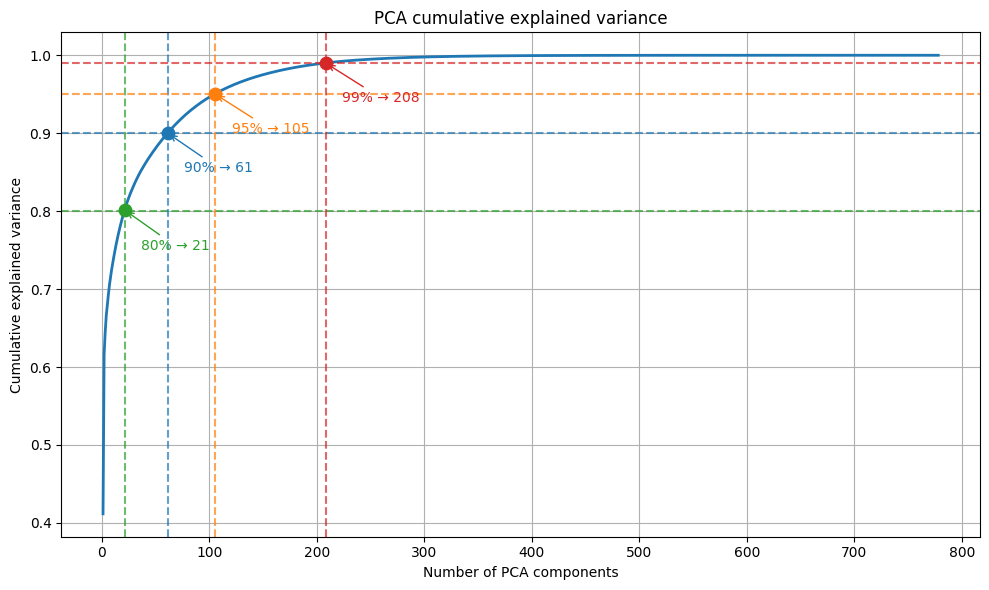

Components needed:
80% variance -> 21 components
90% variance -> 61 components
95% variance -> 105 components
99% variance -> 208 components


In [20]:
# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# PCA fit
pca_full = PCA()
pca_full.fit(X_train_scaled)

# Cumulative variance
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_components = np.arange(1, len(cum_var) + 1)

# Plot base
plt.figure(figsize=(10, 6))
plt.plot(n_components, cum_var, linewidth=2)
plt.xlabel("Number of PCA components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA cumulative explained variance")
plt.grid(True)

# Thresholds with distinct colors
thresholds = [0.80, 0.90, 0.95, 0.99]
colors = ["tab:green", "tab:blue", "tab:orange", "tab:red"]

for thr, color in zip(thresholds, colors):
    k = np.argmax(cum_var >= thr) + 1

    # horizontal line
    plt.axhline(y=thr, linestyle='--', color=color, alpha=0.7)

    # vertical line
    plt.axvline(x=k, linestyle='--', color=color, alpha=0.7)

    # highlight point
    plt.scatter(k, cum_var[k-1], color=color, s=80, zorder=5)

    # annotation (spostata per non sovrapporsi)
    plt.annotate(
        f"{int(thr*100)}% → {k}",
        xy=(k, cum_var[k-1]),
        xytext=(k + len(cum_var)*0.02, thr - 0.05),
        arrowprops=dict(arrowstyle="->", color=color),
        fontsize=10,
        color=color
    )

plt.tight_layout()
plt.show()

# Print values
print("Components needed:")
for thr in thresholds:
    k = np.argmax(cum_var >= thr) + 1
    print(f"{int(thr*100)}% variance -> {k} components")

## Assignment #2.4 — Hyperparameter tuning with [`RandomizedSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html)
Now we tune the full Pipeline. This is the recommended sklearn workflow because CV happens *inside* the pipeline.


In [22]:
param_distributions =  {
    "pca__n_components": [0.80, 0.90, 0.95, 0.99],
    "svc__C": loguniform(1e-3, 1e3),
    "svc__gamma": loguniform(1e-4, 1e-1),
    "svc__kernel": ["rbf", "poly"]
}

search = RandomizedSearchCV(
    estimator=pipe_pca,
    param_distributions=param_distributions,
    n_iter=20,
    cv=3,
    scoring="balanced_accuracy",
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

step_name = "SVC - scaling + PCA + CV"
#Fit the search!
search.fit(X_train, y_train)
r4 = evaluate_step(search, X_test, y_test, step_name)
results.append((step_name, r4))

print("Best params:", r4["model"].best_params_)
print("Best CV score:", r4["model"].best_score_)

pd.DataFrame([{
    "step": name,
    "accuracy": r["acc"],
    "balanced_accuracy": r["bal_acc"],
    "f1_macro": r["f1_macro"],
    "pred_s": round(r["pred_s"], 2),
} for name, r in results])


Fitting 3 folds for each of 20 candidates, totalling 60 fits
STEP: SVC - scaling + PCA + CV
Accuracy:           0.544
Balanced Accuracy:  0.551
Macro F1-score:     0.559
Predict time (s):   0.03
Best params: {'pca__n_components': 0.95, 'svc__C': np.float64(793.2047656808546), 'svc__gamma': np.float64(0.0025135566617708314), 'svc__kernel': 'rbf'}
Best CV score: 0.5697150409457562


,step,accuracy,balanced_accuracy,f1_macro,pred_s
0,SVC - no scaling,0.194872,0.105653,0.069607,0.14
1,SVC - scaling,0.471795,0.410478,0.346983,0.12
2,SVC - scaling + PCA,0.461538,0.409253,0.353838,0.09
3,SVC - scaling + PCA + CV,0.543590,0.550561,0.559150,0.03


## Assignment #3 — Final model report

We take the best estimator found by the search (see [best_estimator_ in RandomizedSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html#randomizedsearchcv)) and print a [classification report](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html#classification-report).


In [23]:
best_model = search.best_estimator_
pred = best_model.predict(X_test)

print(classification_report(y_test, pred, zero_division=0))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       0.33      0.60      0.43         5
           2       0.38      0.60      0.46         5
           3       0.34      0.67      0.45        18
           4       0.36      0.33      0.35        12
           5       0.50      0.40      0.44         5
           6       0.50      0.20      0.29         5
           7       0.67      0.59      0.62        17
           8       0.75      0.55      0.63        11
           9       0.50      0.40      0.44         5
          10       0.60      0.60      0.60         5
          11       0.64      0.56      0.60        16
          12       0.56      0.45      0.50        11
          13       0.50      0.40      0.44         5
          14       0.67      0.40      0.50         5
          15       0.00      0.00      0.00         5
          16       0.50      0.40      0.44         5
          17       0.50    

### Confusion matrix
With many classes, the confusion matrix can be large; still, it can highlight systematic confusions.


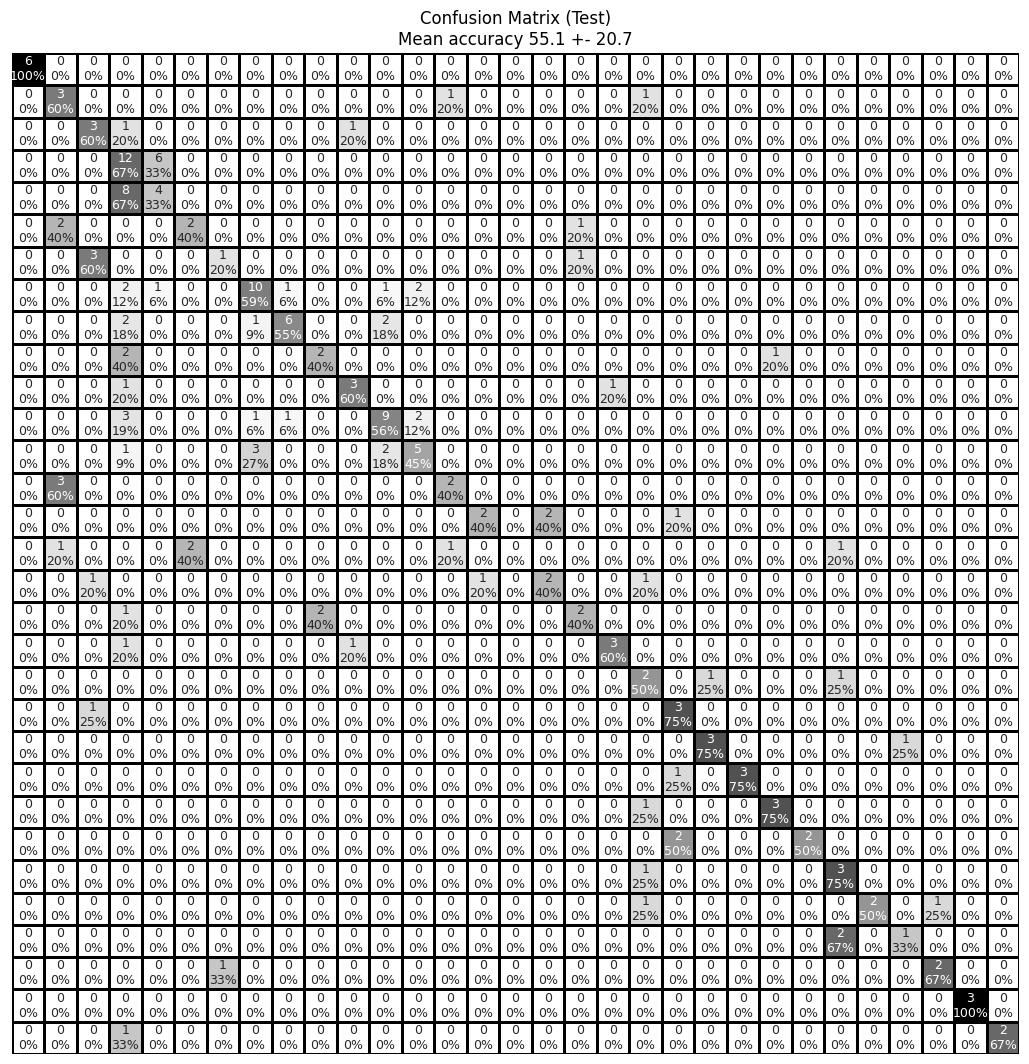

In [24]:
cm = confusion_matrix(y_test, pred, labels=np.unique(y_test))
fig, ax = plt.subplots(1, 1, figsize=(13, 13))
seaborn_cm(cm, ax, [l for l in np.unique(y_test)], fontsize=9, xrotation=90, title="Confusion Matrix (Test)")
plt.show()

### Best parameters

In [25]:
display(
    pd.DataFrame(search.best_params_.items(), columns=["parameter", "value"])
    .sort_values("parameter")
    .reset_index(drop=True)
)

print("Best CV balanced_accuracy:", round(search.best_score_, 4))

,parameter,value
0,pca__n_components,0.95
1,svc__C,793.204766
2,svc__gamma,0.002514
3,svc__kernel,rbf


Best CV balanced_accuracy: 0.5697


## Assignment #4 — Random Forest

Build and evaluate a Random Forest model.

Suggestions:
- Use a tree-based classifier from [`sklearn.ensemble`](https://scikit-learn.org/stable/api/sklearn.ensemble.html).
- Since Random Forest is based on decision trees, **feature scaling is not needed**:
  decision trees split data using thresholds (e.g. `feature ≤ value`) and depend only on the **ordering of values**, not on their scale.  
  Scaling (e.g. StandardScaler) does not change this ordering, so it does not improve the model.

- **Do not include PCA in the first version**: tree-based models usually work better on the original features, while PCA creates linear combinations that may remove useful split information.

Pipeline:
- Build a pipeline with **only the classifier**.
- Set `random_state`.
- Enable parallelization with `n_jobs=-1`.
- If the classes are imbalanced, consider using `class_weight="balanced"`.

Hyperparameters:
- Tune a small set of important parameters, for example:
  - number of trees
  - maximum depth
  - minimum samples for split / leaf
  - number of features considered at each split
- Keep the search space small to avoid long execution times.

Model selection:
- Use [`RandomizedSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html#randomizedsearchcv).
- Use a reasonable number of iterations and folds (for example, a small `n_iter` and `cv=3`).

Evaluation:
- Use the same evaluation function as before.

Final:
- Compare the Random Forest results with SVM.
- After that, you may also try adding PCA and check whether performance improves or worsens.
- Briefly try to explain why PCA may help SVM but not Random Forest.

*Answer*


PCA can help SVM because SVM relies on distances and geometry in feature space.
By reducing noise and compressing correlated features into a lower-dimensional space, PCA can make class boundaries easier to separate and improve efficiency.

In contrast, Random Forest does not rely on distances but on threshold-based splits on individual features.
PCA transforms the original features into linear combinations, which can hide the simple patterns that trees exploit, often leading to worse performance.

In [34]:
from sklearn.ensemble import RandomForestClassifier

pipe_rf = Pipeline([
    ('rf', RandomForestClassifier(
        random_state= SEED,
        n_jobs=-1,
        class_weight="balanced"
    ))
])


param_distributions_rf = param_distributions_rf = {
    'rf__n_estimators': [100, 200, 300],         # Number of trees
    'rf__max_depth': [None, 10, 20, 30],         # maximum depth
    'rf__min_samples_split': [2, 5, 10],         # minimum samples for split / leaf
    'rf__max_features': ['sqrt', 'log2']         # number of features considered at each split
}
search_rf = RandomizedSearchCV(
    estimator=pipe_rf,
    param_distributions=param_distributions_rf,
    n_iter=15,
    cv=3,
    scoring="balanced_accuracy",
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)


step_name = "RF - no PCA"
# Fit the search!
search_rf.fit(X_train, y_train)
r_rf = evaluate_step(search_rf, X_test, y_test, step_name)

print("Best params:", r_rf["model"].best_params_)
print("Best CV score:", r_rf["model"].best_score_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
STEP: RF - no PCA
Accuracy:           0.995
Balanced Accuracy:  0.998
Macro F1-score:     0.997
Predict time (s):   0.08
Best params: {'rf__n_estimators': 300, 'rf__min_samples_split': 10, 'rf__max_features': 'sqrt', 'rf__max_depth': 30}
Best CV score: 0.995400238948626


### Confusion matrix


              precision    recall  f1-score   support

           0       0.86      1.00      0.92         6
           1       1.00      1.00      1.00         5
           2       1.00      1.00      1.00         5
           3       1.00      1.00      1.00        18
           4       1.00      1.00      1.00        12
           5       1.00      1.00      1.00         5
           6       1.00      1.00      1.00         5
           7       1.00      0.94      0.97        17
           8       1.00      1.00      1.00        11
           9       1.00      1.00      1.00         5
          10       1.00      1.00      1.00         5
          11       1.00      1.00      1.00        16
          12       1.00      1.00      1.00        11
          13       1.00      1.00      1.00         5
          14       1.00      1.00      1.00         5
          15       1.00      1.00      1.00         5
          16       1.00      1.00      1.00         5
          17       1.00    

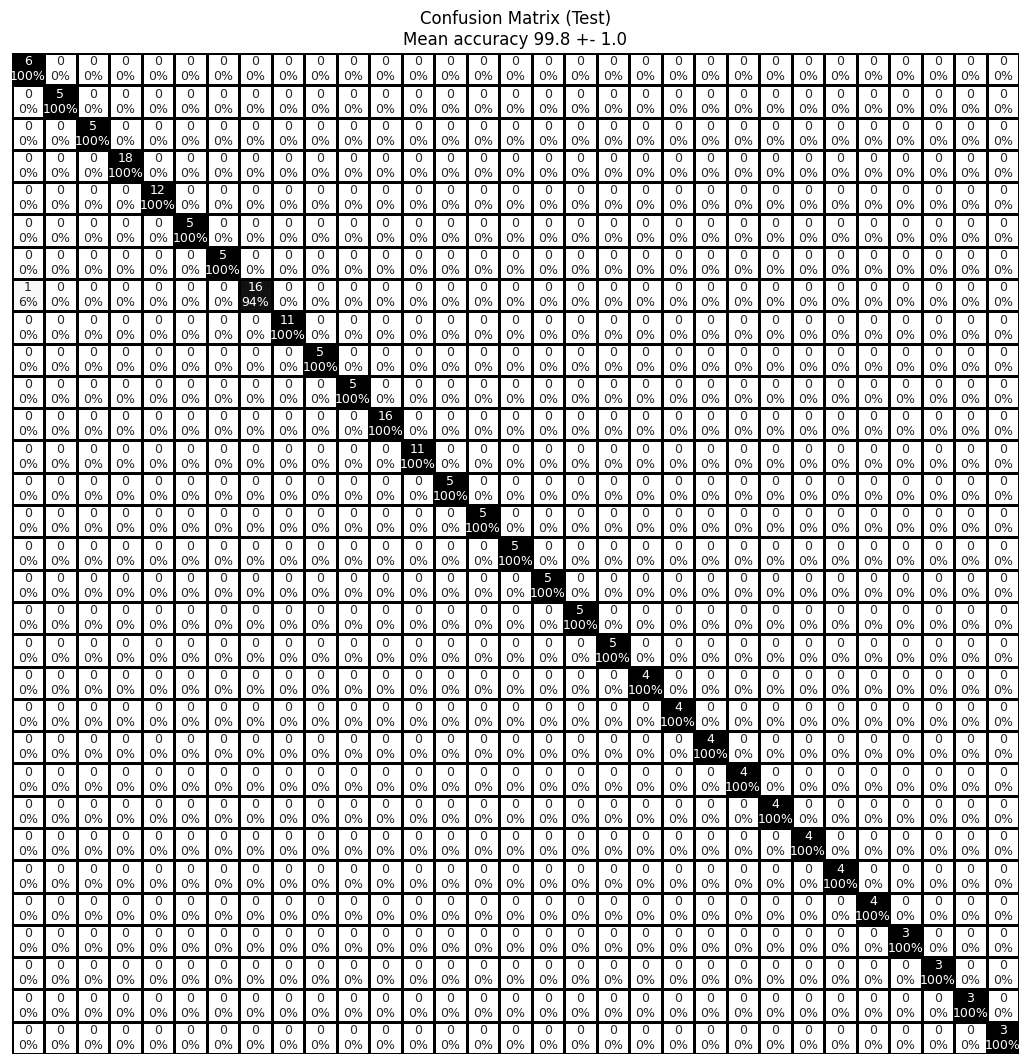

In [35]:
best_model = search_rf.best_estimator_
pred = best_model.predict(X_test)

print(classification_report(y_test, pred, zero_division=0))

cm = confusion_matrix(y_test, pred, labels=np.unique(y_test))
fig, ax = plt.subplots(1, 1, figsize=(13, 13))
seaborn_cm(cm, ax, [l for l in np.unique(y_test)], fontsize=9, xrotation=90, title="Confusion Matrix (Test)")
plt.show()